In [2]:
!pip install -q torch_snippets
from torch_snippets import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataset = datasets.MNIST(root='MNIST/', train=True, transform=transforms.ToTensor(), download= True)
test_dataset = datasets.MNIST(root='MNIST/', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.0 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.70MB/s]


In [3]:
train_dataset[0][0]

tensor[1, 28, 28] n=784 (3.06 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.138 σ=0.313

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()

    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
    self.fc1 = nn.Linear(64 * 7 * 7, 256)
    self.fc21 = nn.Linear(256, 20)
    self.fc22 = nn.Linear(256, 20)

    self.fc3 = nn.Linear(20, 256)
    self.fc4 = nn.Linear(256, 64 * 7 * 7)
    self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
    self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

  def encode(self, x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    mu = self.fc21(x)
    logvar = self.fc22(x)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    if self.training:
      std = torch.exp(0.5 * logvar)
      eps = Variable(torch.randn(std.size())).cpu()
      return eps.mul(std).add_(mu)
    else:
      return mu

  def decode(self, z):
    z = F.relu(self.fc3(z))
    z = F.relu(self.fc4(z))
    z = z.view(z.size(0), 64, 7, 7)
    z = F.relu(self.deconv1(z))
    z = torch.sigmoid(self.deconv2(z))
    return z

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    z = self.decode(z)
    return z, mu, logvar

In [24]:
# class VAE(nn.Module):
#   def _init__(self, x_dim, h_dim1, h_dim2, z_dim):
#     super(VAE, self).__init__()
#     self.d1 = nn.Linear(x_dim, h_dim1)
#     self.d2 = nn.Linear(h_dimi, h_dim2)
#     self.d31 = nn. Linear(h_dim2, z_dim)
#     self.d32 = nn. Linear(h_dim2, z_dim)
#     self.d4 = nn.Linear(z_dim, h_dim2)
#     self.d5 = nn.Linear(h_dim2, h_dim1)
#     self.d6 = nn.Linear(h_dimi, x_dim)
#   def encoder(self, x):
#     h = F.relu(self.d1(x))
#     h = F.relu(self.d2(h))
#     return self.d31(h), self.d32(h)
#   def sampling(self, mean, log_var):
#     std = torch.exp(0.5*log_var)
#     eps = torch.randn_like(std)
#     return eps.mul(std).add_(mean)
#   def decoder(self, z):
#     h = F.relu(self.d4(z))
#     h = F.relu(self.d5(h))
#     return F.sigmoid(self.d6(h))
#   def forward(self, x):
#     mean, log_var = self.encoder(x.view(-1, 784))
#     z= self.sampling (mean, log_var)
#     return self.decoder(z), mean, log_var

In [25]:
def train_batch(data, model, optimizer, loss_function):
  model.train()
  data = data.to(device)
  optimizer.zero_grad()
  recon_batch, mean, log_var = model(data)
  loss, mse, kld = loss_function(recon_batch, data, mean, log_var)
  loss.backward()
  optimizer.step()
  return loss, mse, kld, log_var.mean(), mean.mean()

@torch.no_grad()
def validate_batch(data, model, loss_function):
  model.eval()
  data = data.to(device)
  recon, mean, log_var = model (data)
  loss, mse, kld = loss_function(recon, data, mean, log_var)
  return loss, mse, kld, log_var.mean(), mean.mean()

In [26]:
def loss_function(recon_x, x, mean, log_var):
  RECON = F.mse_loss(recon_x, x, reduction='sum')
  KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
  return RECON + KLD, RECON, KLD

EPOCH: 1.000  train_loss: 2743.988  train_kld: 356.776  train_recon: 2387.212  val_mean: -0.018  train_log_var: -0.528  val_log_var: -0.920  val_kld: 579.939  val_recon: 1355.237  val_loss: 1935.176  train_mean: 0.001  (79.28s - 713.53s remaining)


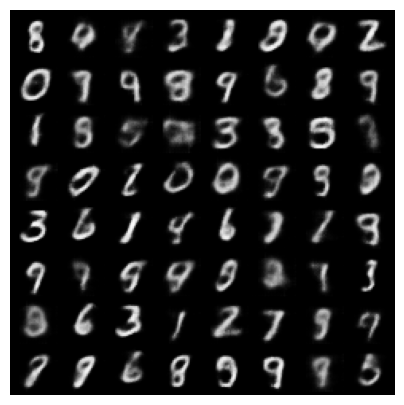

EPOCH: 2.000  train_loss: 2053.606  train_kld: 615.769  train_recon: 1437.837  val_mean: -0.008  train_log_var: -0.953  val_log_var: -1.045  val_kld: 694.301  val_recon: 1049.259  val_loss: 1743.560  train_mean: -0.001  (166.31s - 665.25s remaining)


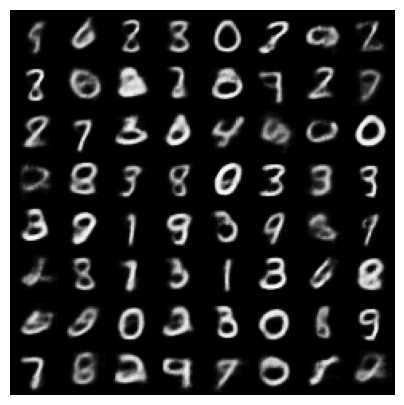

EPOCH: 3.000  train_loss: 1951.588  train_kld: 669.451  train_recon: 1282.137  val_mean: -0.000  train_log_var: -1.043  val_log_var: -1.068  val_kld: 681.179  val_recon: 942.980  val_loss: 1624.159  train_mean: 0.001  (253.93s - 592.51s remaining)


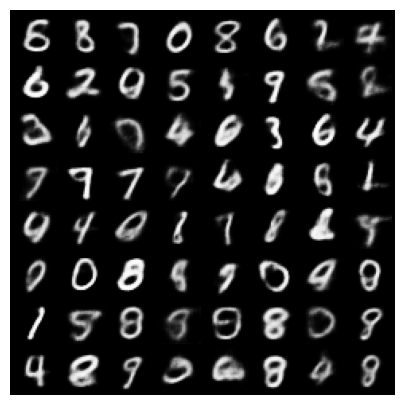

EPOCH: 4.000  train_loss: 1903.418  train_kld: 694.298  train_recon: 1209.120  val_mean: 0.003  train_log_var: -1.084  val_log_var: -1.129  val_kld: 715.797  val_recon: 883.420  val_loss: 1599.217  train_mean: 0.000  (342.18s - 513.27s remaining)


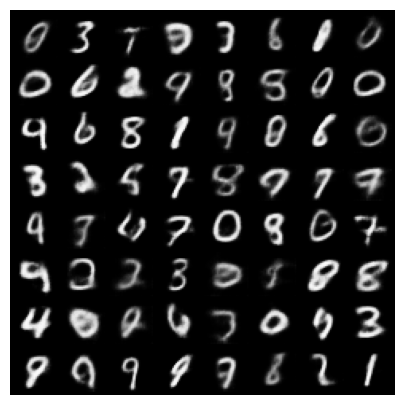

EPOCH: 5.000  train_loss: 1873.258  train_kld: 708.010  train_recon: 1165.248  val_mean: -0.001  train_log_var: -1.106  val_log_var: -1.104  val_kld: 697.604  val_recon: 857.257  val_loss: 1554.861  train_mean: -0.000  (431.66s - 431.66s remaining)


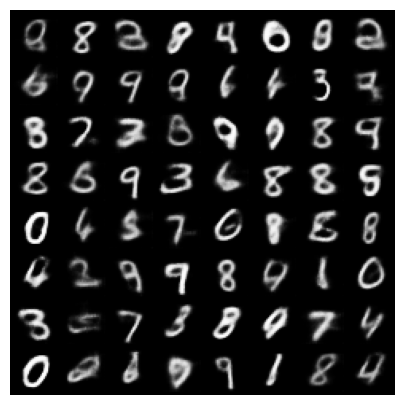

EPOCH: 6.000  train_loss: 1852.263  train_kld: 716.314  train_recon: 1135.948  val_mean: 0.009  train_log_var: -1.119  val_log_var: -1.158  val_kld: 742.828  val_recon: 829.778  val_loss: 1572.606  train_mean: 0.000  (521.65s - 347.77s remaining)


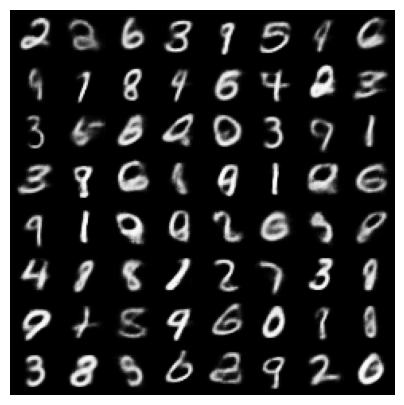

EPOCH: 7.000  train_loss: 1837.531  train_kld: 723.062  train_recon: 1114.469  val_mean: 0.011  train_log_var: -1.130  val_log_var: -1.154  val_kld: 736.184  val_recon: 819.401  val_loss: 1555.585  train_mean: 0.000  (610.54s - 261.66s remaining)


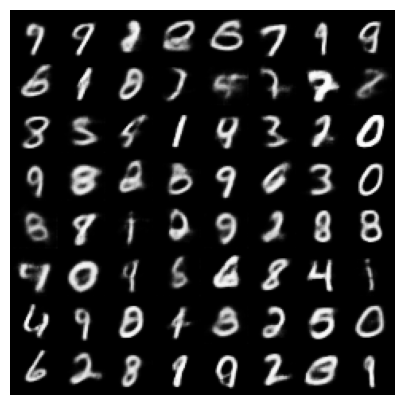

EPOCH: 8.000  train_loss: 1825.155  train_kld: 727.243  train_recon: 1097.912  val_mean: 0.011  train_log_var: -1.137  val_log_var: -1.188  val_kld: 756.338  val_recon: 824.144  val_loss: 1580.481  train_mean: -0.000  (699.38s - 174.84s remaining)


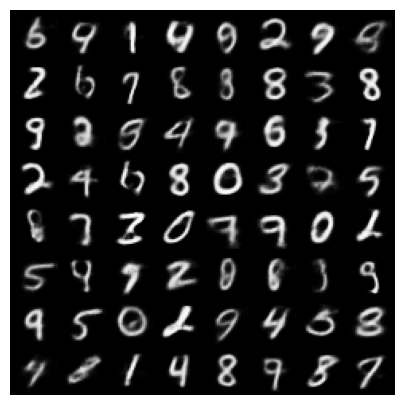

EPOCH: 9.000  train_loss: 1815.230  train_kld: 731.344  train_recon: 1083.886  val_mean: 0.010  train_log_var: -1.144  val_log_var: -1.130  val_kld: 731.085  val_recon: 798.224  val_loss: 1529.309  train_mean: -0.000  (789.28s - 87.70s remaining)


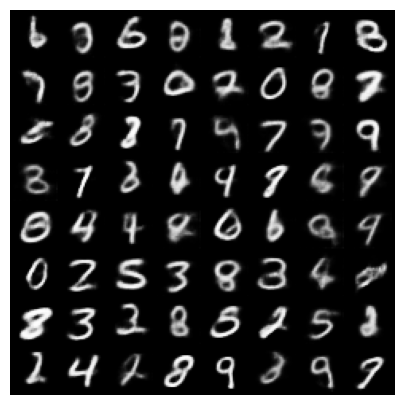

EPOCH: 10.000  train_loss: 1804.812  train_kld: 733.881  train_recon: 1070.931  val_mean: 0.004  train_log_var: -1.147  val_log_var: -1.163  val_kld: 742.058  val_recon: 776.722  val_loss: 1518.779  train_mean: 0.000  (879.47s - 0.00s remaining)


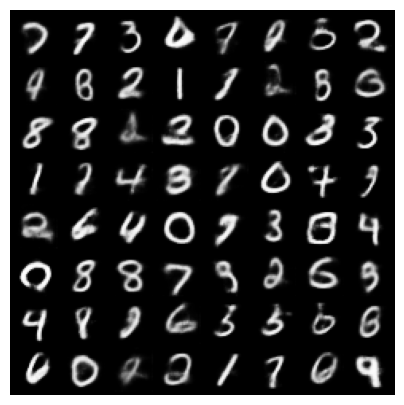

In [28]:
n_epochs = 10
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

for epoch in range(n_epochs):
  N = len(train_loader)
  for batch_idx, (data, _) in enumerate(train_loader):
    loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
    pos = epoch + (1+batch_idx)/N
    log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

  N = len(test_loader)
  for batch_idx, (data, _) in enumerate(test_loader):
    loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
    pos = epoch + (1+batch_idx)/N
    log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

  log.report_avgs(epoch+1)
  with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    sample = vae.decode(z).to(device)
    images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
    show(images)